# Analise exploratoria - Historicos multivar

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## 1. Matriz de correlação

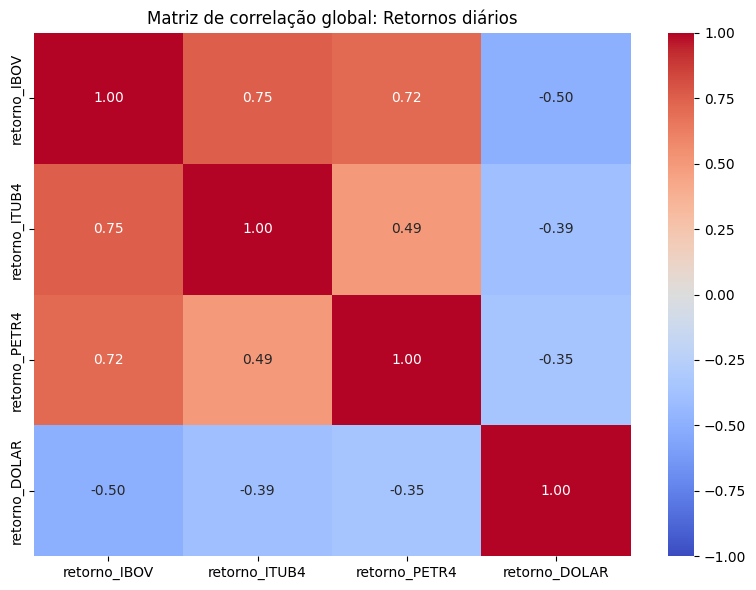

In [56]:
df_ibov = pd.read_csv('dados/ibov_multivar.csv')
df_itub = pd.read_csv('dados/itub4_multivar.csv')
df_petr = pd.read_csv('dados/petr4_multivar.csv')
df_dolar = pd.read_csv('dados/dolar_multivar.csv')
df_ibov_r = df_ibov[['date', 'return']].rename(columns={'return': 'retorno_IBOV'})
df_itub_r = df_itub[['date', 'return']].rename(columns={'return': 'retorno_ITUB4'})
df_petr_r = df_petr[['date', 'return']].rename(columns={'return': 'retorno_PETR4'})
df_dolar_r = df_dolar[['date', 'return']].rename(columns={'return': 'retorno_DOLAR'})

df_unif = pd.merge(df_ibov_r, df_itub_r, on='date', how='inner')
df_unif = pd.merge(df_unif, df_petr_r, on='date', how='inner')
df_unif = pd.merge(df_unif, df_dolar_r, on='date', how='inner')

# gerando a matriz de correlação
cols = ['retorno_IBOV', 'retorno_ITUB4', 'retorno_PETR4', 'retorno_DOLAR']
mat_corr = df_unif[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(mat_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlação global: Retornos diários')
plt.tight_layout()
plt.show()

## 2. Historico retornos diarios

In [57]:
# convertendo data
df_unif['date'] = pd.to_datetime(df_unif['date'])

cores = ['red', 'blue']
cols_retorno = ['retorno_ITUB4', 'retorno_PETR4']

# Criando figura interativa com plotly
fig = go.Figure()

for col, cor in zip(cols_retorno, cores):
    fig.add_trace(go.Scatter(
        x=df_unif['date'],
        y=df_unif[col],
        mode='lines',
        name=col.replace('retorno_', ''),
        line=dict(color=cor, width=2),
        opacity=0.5
    ))

fig.update_layout(
    title='Histórico de retornos diários',
    xaxis_title='Data',
    yaxis_title='Retorno',
    hovermode='x unified',
    template='plotly_white',
    height=500,
    width=1000
)

fig.show()

In [58]:
# convertendo data
df_unif['date'] = pd.to_datetime(df_unif['date'])

cores = ['red', 'blue']
cols_retorno = ['retorno_IBOV', 'retorno_DOLAR']

# Criando figura interativa com plotly
fig = go.Figure()

for col, cor in zip(cols_retorno, cores):
    fig.add_trace(go.Scatter(
        x=df_unif['date'],
        y=df_unif[col],
        mode='lines',
        name=col.replace('retorno_', ''),
        line=dict(color=cor, width=2),
        opacity=0.5
    ))

fig.update_layout(
    title='Histórico de retornos diários',
    xaxis_title='Data',
    yaxis_title='Retorno',
    hovermode='x unified',
    template='plotly_white',
    height=500,
    width=1000
)

fig.show()

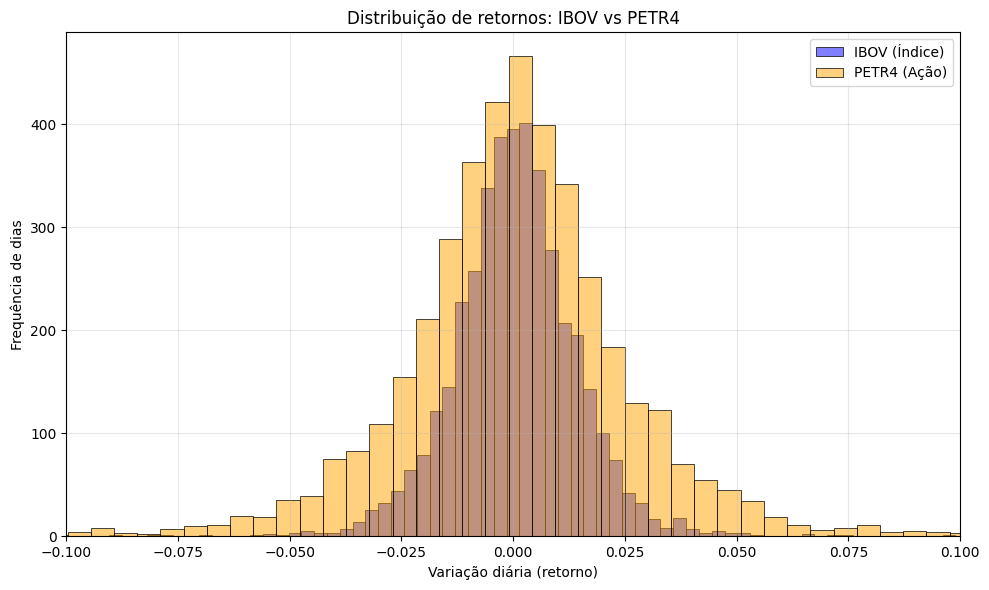

In [59]:
plt.figure(figsize=(10, 6))
sns.histplot(df_ibov['return'].dropna(), bins=100, color='blue', alpha=0.5, label='IBOV (Índice)')
sns.histplot(df_petr['return'].dropna(), bins=100, color='orange', alpha=0.5, label='PETR4 (Ação)')

plt.title('Distribuição de retornos: IBOV vs PETR4')
plt.xlabel('Variação diária (retorno)')
plt.ylabel('Frequência de dias')
plt.xlim(-0.1, 0.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

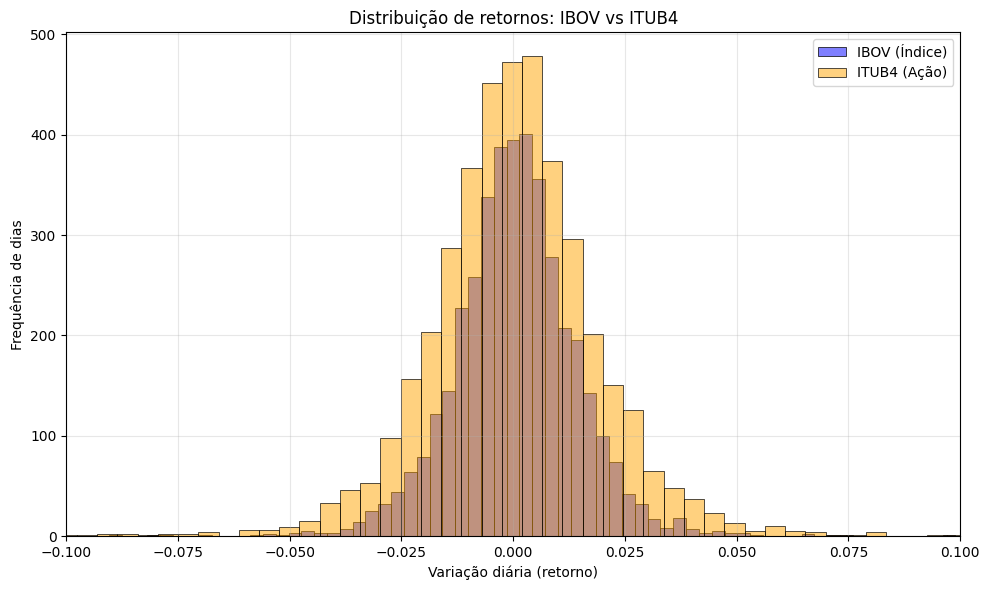

In [60]:
plt.figure(figsize=(10, 6))
sns.histplot(df_ibov['return'].dropna(), bins=100, color='blue', alpha=0.5, label='IBOV (Índice)')
sns.histplot(df_itub['return'].dropna(), bins=100, color='orange', alpha=0.5, label='ITUB4 (Ação)')

plt.title('Distribuição de retornos: IBOV vs ITUB4')
plt.xlabel('Variação diária (retorno)')
plt.ylabel('Frequência de dias')
plt.xlim(-0.1, 0.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

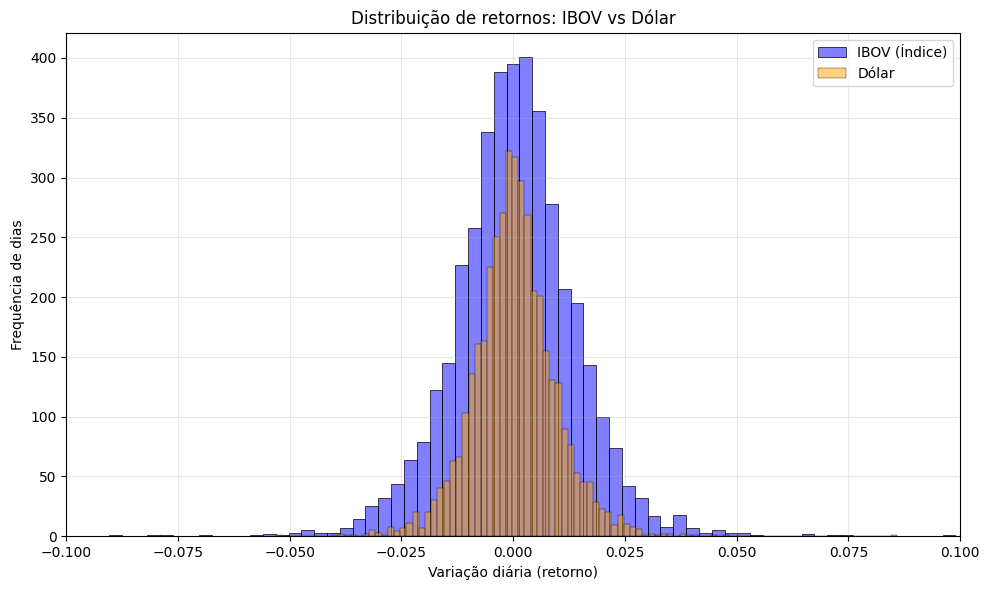

In [61]:
plt.figure(figsize=(10, 6))
sns.histplot(df_ibov['return'].dropna(), bins=100, color='blue', alpha=0.5, label='IBOV (Índice)')
sns.histplot(df_dolar['return'].dropna(), bins=100, color='orange', alpha=0.5, label='Dólar')

plt.title('Distribuição de retornos: IBOV vs Dólar')
plt.xlabel('Variação diária (retorno)')
plt.ylabel('Frequência de dias')
plt.xlim(-0.1, 0.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

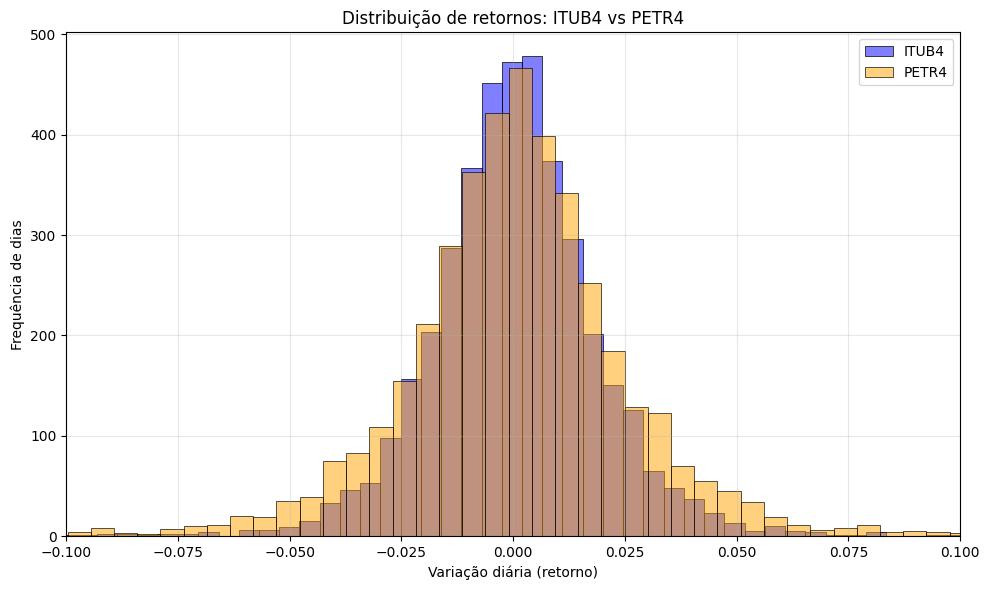

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(df_itub['return'].dropna(), bins=100, color='blue', alpha=0.5, label='ITUB4')
sns.histplot(df_petr['return'].dropna(), bins=100, color='orange', alpha=0.5, label='PETR4')

plt.title('Distribuição de retornos: ITUB4 vs PETR4')
plt.xlabel('Variação diária (retorno)')
plt.ylabel('Frequência de dias')
plt.xlim(-0.1, 0.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

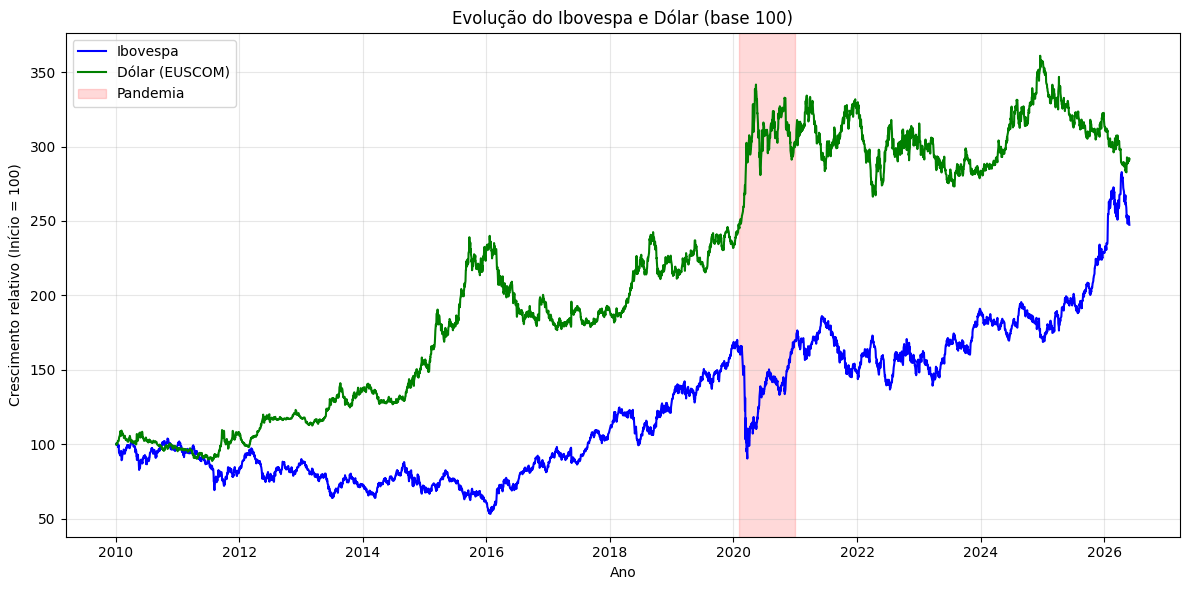

In [66]:
df_ibov_c = df_ibov[['date', 'closed']].rename(columns={'closed': 'IBOV'})
df_dolar_c = df_dolar[['date', 'closed']].rename(columns={'closed': 'DOLAR'})

df_unif = pd.merge(df_ibov_c, df_dolar_c, on='date', how='inner')
df_unif['date'] = pd.to_datetime(df_unif['date'])

# normalização: (Preço atual / Preço do dia 1) * 100
df_unif['IBOV_Norm'] = (df_unif['IBOV'] / df_unif['IBOV'].iloc[0]) * 100
df_unif['DOLAR_Norm'] = (df_unif['DOLAR'] / df_unif['DOLAR'].iloc[0]) * 100

plt.figure(figsize=(12, 6))
plt.plot(df_unif['date'], df_unif['IBOV_Norm'], label='Ibovespa', color='blue', linewidth=1.5)
plt.plot(df_unif['date'], df_unif['DOLAR_Norm'], label='Dólar (EUSCOM)', color='green', linewidth=1.5)

plt.title('Evolução do Ibovespa e Dólar (base 100)')
plt.xlabel('Ano')
plt.ylabel('Crescimento relativo (Início = 100)')

# pandemia
plt.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-12-31'), color='red', alpha=0.15, label='Pandemia')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Gráficos candlestick

In [64]:
# últimos 60 dias para melhor visualização
df_60 = df_petr.tail(60).copy()

# preço em cima e volume embaixo
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.03, row_heights=[0.7, 0.3])

# candlestick na linha 1
fig.add_trace(go.Candlestick(
    x=df_60['date'],
    open=df_60['open'], high=df_60['high'],
    low=df_60['low'], close=df_60['closed'],
    name='OHLC'
), row=1, col=1)

# colorindo o volume de verde (dia de alta) ou vermelho (dia de baixa)
cores_vol = ['green' if close >= open else 'red' 
                for close, open in zip(df_60['closed'], df_60['open'])]

# volume na linha 2
fig.add_trace(go.Bar(
    x=df_60['date'], y=df_60['vol'],
    marker_color=cores_vol, name='Volume'
), row=2, col=1)

fig.update_layout(
    title='PETR4: Preço e volume',
    xaxis_rangeslider_visible=False,
    template='plotly_white',
    height=600
)
fig.show()

In [65]:
# últimos 60 dias para melhor visualização
df_60 = df_itub.tail(60).copy()

# preço em cima e volume embaixo
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.03, row_heights=[0.7, 0.3])

# candlestick na linha 1
fig.add_trace(go.Candlestick(
    x=df_60['date'],
    open=df_60['open'], high=df_60['high'],
    low=df_60['low'], close=df_60['closed'],
    name='OHLC'
), row=1, col=1)

# colorindo o volume de verde (dia de alta) ou vermelho (dia de baixa)
cores_vol = ['green' if close >= open else 'red' 
                for close, open in zip(df_60['closed'], df_60['open'])]

# volume na linha 2
fig.add_trace(go.Bar(
    x=df_60['date'], y=df_60['vol'],
    marker_color=cores_vol, name='Volume'
), row=2, col=1)

fig.update_layout(
    title='ITUB4: Preço e volume',
    xaxis_rangeslider_visible=False,
    template='plotly_white',
    height=600
)
fig.show()